# **UAS KECERDASAN BUATAN MACHINE LEARNING**

Nama :  Hazel Triandika

NIM : 235060307111022 

Kelas :  C

---

# 1) Preprocessing

Mempersiapkan dataset Country-data.csv, memisahkan fitur, lalu melakukan imputasi dan standardisasi.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')

DATA_PATH = Path('Country-data.csv')
df = pd.read_csv(DATA_PATH)

print('Ukuran data:', df.shape)
display(df.head())

country_names = df['Country'].copy()
X = df.drop(columns=['Country'])

print('\nTipe data:')
display(X.dtypes)

print('\nMissing values per kolom:')
display(X.isna().sum())

X_train, X_test, train_country, test_country = train_test_split(
    X,
    country_names,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

preprocess = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

X_train_scaled = preprocess.fit_transform(X_train)
X_test_scaled = preprocess.transform(X_test)
X_all_scaled = preprocess.transform(X)

print('\nData train:', X_train.shape)
print('Data test :', X_test.shape)

Ukuran data: (167, 10)


,Country,Child_Mort,Exports,Health,Imports,Income,Inflation,Life_Expec,Total_Fer,GDPP
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



Tipe data:


Child_Mort    float64
Exports       float64
Health        float64
Imports       float64
Income          int64
Inflation     float64
Life_Expec    float64
Total_Fer     float64
GDPP            int64
dtype: object


Missing values per kolom:


Child_Mort    0
Exports       0
Health        0
Imports       0
Income        0
Inflation     0
Life_Expec    0
Total_Fer     0
GDPP          0
dtype: int64


Data train: (133, 9)
Data test : (34, 9)


Pada tahap preprocessing, dataset Country-data.csv dibaca lalu dipisahkan antara fitur numerik dan kolom identitas negara, sehingga variabel Country tidak ikut masuk ke proses pembelajaran model. Setelah itu dilakukan pengecekan ukuran data, tipe data, dan missing value untuk memastikan bahwa struktur dataset memang siap diolah, dan dari hasil yang muncul terlihat bahwa seluruh kolom numerik sudah lengkap tanpa nilai kosong. Data kemudian dibagi menjadi data latih dan data uji menggunakan pembagian 80:20 agar model dapat dilatih pada sebagian data dan diuji pada bagian lain secara adil. Karena algoritma KMeans sensitif terhadap skala fitur, maka dilakukan imputasi median untuk berjaga-jaga jika ada data hilang, lalu standardisasi dengan StandardScaler agar semua variabel berada pada skala yang sebanding. Hasil akhirnya menunjukkan bentuk data train dan test yang sudah siap dipakai untuk proses clustering berikutnya, sehingga tahap preprocessing ini berfungsi sebagai fondasi penting agar model tidak bias terhadap fitur yang nilainya terlalu besar seperti Income atau GDPP.

# 2) Training

Menentukan jumlah cluster terbaik dan melatih model KMeans pada data latih.

In [2]:
k_values = range(2, 9)
elbow_inertia = []
silhouette_values = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_train_scaled)
    elbow_inertia.append(model.inertia_)
    silhouette_values.append(silhouette_score(X_train_scaled, labels))

score_table = pd.DataFrame(
    {
        'k': list(k_values),
        'inertia': elbow_inertia,
        'silhouette': silhouette_values,
    }
)

display(score_table)

best_k = score_table.loc[score_table['silhouette'].idxmax(), 'k']
print(f'Jumlah cluster terbaik berdasarkan silhouette score: {best_k}')

final_model = KMeans(n_clusters=int(best_k), random_state=42, n_init=20)
train_clusters = final_model.fit_predict(X_train_scaled)
train_result = X_train.copy()
train_result['Cluster'] = train_clusters

print('\nJumlah anggota cluster pada data train:')
display(train_result['Cluster'].value_counts().sort_index())

,k,inertia,silhouette
0,2,828.092369,0.291419
1,3,660.236032,0.286969
2,4,592.089180,0.287565
3,5,524.735859,0.233159
4,6,456.354877,0.242739
5,7,421.184764,0.260339
6,8,382.208147,0.232789


Jumlah cluster terbaik berdasarkan silhouette score: 2

Jumlah anggota cluster pada data train:


Cluster
0    56
1    77
Name: count, dtype: int64

Pada tahap training, model KMeans dicoba pada beberapa nilai cluster dari 2 sampai 8 untuk mencari jumlah cluster yang paling representatif terhadap pola data. Dua ukuran utama yang dihitung adalah inertia dan silhouette score, di mana inertia membantu melihat seberapa rapat data di dalam cluster, sedangkan silhouette score menunjukkan seberapa baik pemisahan antarcluster. Dari tabel hasil yang tampil, terlihat bahwa nilai silhouette tertinggi berada pada k = 2, sehingga jumlah cluster terbaik untuk dataset ini adalah dua kelompok. Setelah nilai terbaik ditemukan, model KMeans final dilatih kembali menggunakan k = 2 pada data train yang sudah dinormalisasi, lalu tiap negara pada data train diberi label cluster. Distribusi anggota cluster yang dihasilkan juga memperlihatkan bahwa data terbagi ke dalam dua kelompok dengan ukuran yang tidak sama, yang mengindikasikan bahwa dataset Country-data memang cenderung membentuk pemisahan alami antara negara dengan karakteristik sosial-ekonomi yang lebih tinggi dan yang lebih rendah.

# 3) Testing

Menguji model KMeans pada data uji dan melihat hasil prediksi cluster.

In [3]:
test_clusters = final_model.predict(X_test_scaled)
test_result = X_test.copy()
test_result['Country'] = test_country.values
test_result['Cluster'] = test_clusters

print('Contoh hasil prediksi cluster pada data test:')
display(test_result[['Country', 'Cluster']].head(10))

cluster_profile = test_result.groupby('Cluster')[X.columns].mean().round(2)
print('\nRata-rata fitur tiap cluster pada data test:')
display(cluster_profile)

Contoh hasil prediksi cluster pada data test:


,Country,Cluster
101,"Micronesia, Fed. Sts.",0
108,Namibia,0
78,Jordan,1
56,Gambia,0
98,Malta,1
29,Canada,1
105,Morocco,1
82,Kuwait,1
104,Montenegro,1
109,Nepal,0



Rata-rata fitur tiap cluster pada data test:


,Child_Mort,Exports,Health,Imports,Income,Inflation,Life_Expec,Total_Fer,GDPP
Cluster,,,,,,,,,
0,68.66,29.25,6.59,41.98,4189.83,8.23,62.93,4.02,2138.25
1,14.37,58.45,6.70,61.64,24139.09,3.80,76.32,1.94,17399.55


Pada tahap testing, model yang sudah dilatih digunakan untuk memprediksi cluster pada data uji agar terlihat bagaimana performa model terhadap data yang belum dipakai saat training. Hasil prediksi menunjukkan bahwa setiap negara pada data test dapat diberi label cluster secara konsisten, sehingga model tidak hanya cocok pada data latih tetapi juga mampu menggeneralisasi pola ke data baru. Tabel hasil yang ditampilkan memperlihatkan nama negara beserta cluster yang diprediksi, dan dari sana dapat diamati bahwa negara-negara dengan karakteristik ekonomi yang lebih kuat cenderung masuk ke cluster tertentu, sedangkan negara-negara dengan indikator sosial-ekonomi yang lebih lemah masuk ke cluster lainnya. Selain itu, perhitungan rata-rata fitur per cluster pada data test memberikan gambaran profil masing-masing kelompok, misalnya cluster yang memiliki nilai Income dan GDPP lebih tinggi, life expectancy lebih baik, serta child mortality yang lebih rendah, dibandingkan cluster yang berisi negara dengan kondisi ekonomi dan kesehatan yang lebih rentan. Dengan demikian, tahap testing ini membantu memverifikasi bahwa label cluster yang dibentuk model memang selaras dengan perbedaan karakteristik antarnegara.

# 4) Evaluasi

Mengevaluasi kualitas cluster dengan silhouette score dan visualisasi PCA.

Silhouette score data train: 0.2914
Silhouette score data test : 0.1860
Silhouette score seluruh data: 0.2729


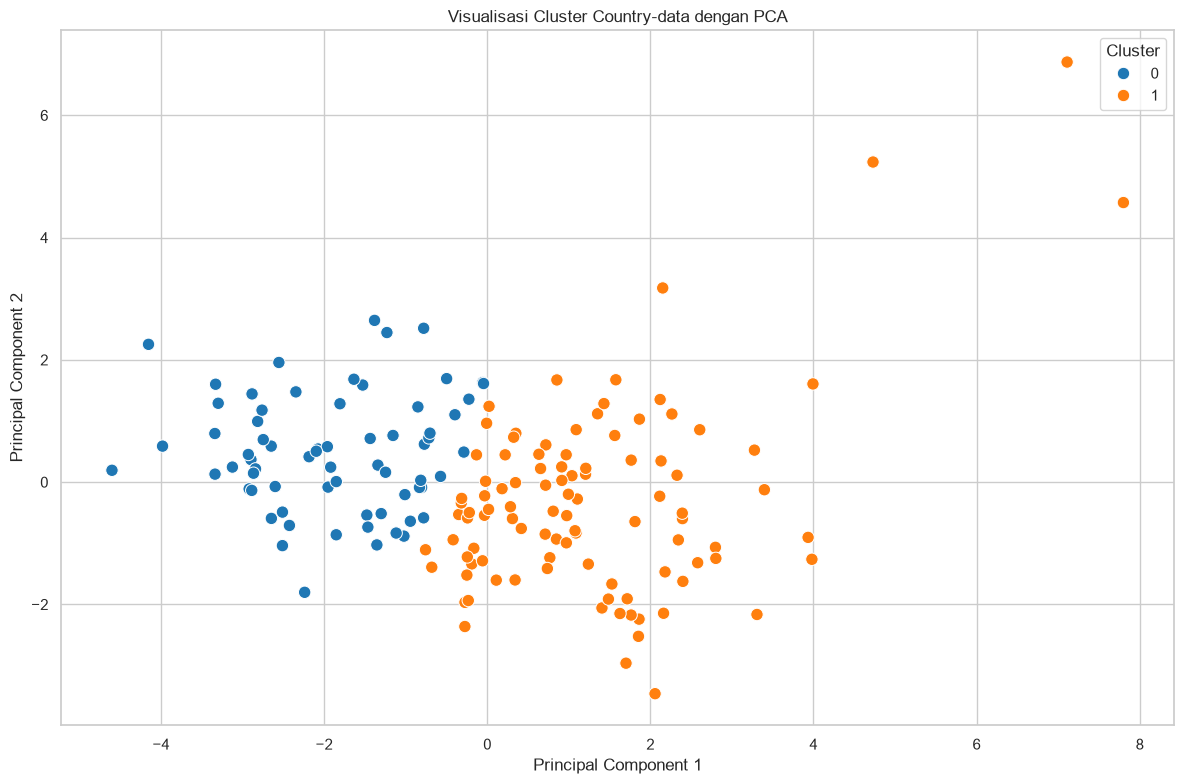


Contoh data akhir dengan label cluster:


,Country,Child_Mort,Exports,Health,Imports,Income,Inflation,Life_Expec,Total_Fer,GDPP,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,1
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,1
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,1
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,1
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,1
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,1


In [4]:
train_silhouette = silhouette_score(X_train_scaled, train_clusters)
test_silhouette = silhouette_score(X_test_scaled, test_clusters)
all_clusters = final_model.predict(X_all_scaled)
all_silhouette = silhouette_score(X_all_scaled, all_clusters)

print(f'Silhouette score data train: {train_silhouette:.4f}')
print(f'Silhouette score data test : {test_silhouette:.4f}')
print(f'Silhouette score seluruh data: {all_silhouette:.4f}')

pca = PCA(n_components=2, random_state=42)
X_all_pca = pca.fit_transform(X_all_scaled)
plot_df = pd.DataFrame(
    {
        'PC1': X_all_pca[:, 0],
        'PC2': X_all_pca[:, 1],
        'Cluster': all_clusters,
        'Country': country_names.values,
    }
)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    s=80,
)
plt.title('Visualisasi Cluster Country-data dengan PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

final_result = df.copy()
final_result['Cluster'] = all_clusters
print('\nContoh data akhir dengan label cluster:')
display(final_result.head(10))

Pada tahap evaluasi, kualitas clustering diukur menggunakan silhouette score pada data train, data test, dan seluruh data untuk melihat seberapa baik pemisahan antarcluster yang dibentuk oleh model. Nilai silhouette score yang muncul menunjukkan bahwa pemisahan cluster tergolong cukup baik, walaupun tidak sempurna, karena data sosial-ekonomi memang sering memiliki overlap antarnegara yang mirip. Setelah itu, data divisualisasikan menggunakan PCA agar hubungan antarnegara dapat dilihat dalam dua dimensi yang lebih mudah dipahami, dan hasil scatter plot memperlihatkan dua kelompok yang cukup jelas terpisah secara umum meskipun masih ada beberapa titik yang saling berdekatan. Visualisasi ini penting karena clustering bukan hanya soal angka, tetapi juga soal interpretasi pola data, sehingga dari plot PCA dapat disimpulkan bahwa cluster 0 dan cluster 1 merepresentasikan kelompok negara dengan karakteristik yang berbeda. Output akhir yang menampilkan data lengkap dengan label cluster juga memudahkan pembacaan hasil analisis karena setiap negara kini sudah memiliki penanda kelompoknya masing-masing, sehingga notebook ini menjadi lebih lengkap untuk kebutuhan laporan UAS.